In [1]:
# 1. Import Libraries
import pandas as pd
import numpy as np

In [21]:
# 2. Load Dataset
df = pd.read_csv("energy_efficiency_data.csv")

In [5]:
# 3. Display dataset information
print(df.head())

   Relative_Compactness  Surface_Area  Wall_Area  Roof_Area  Overall_Height  \
0                  0.98         514.5      294.0     110.25             7.0   
1                  0.98         514.5      294.0     110.25             7.0   
2                  0.98         514.5      294.0     110.25             7.0   
3                  0.98         514.5      294.0     110.25             7.0   
4                  0.90         563.5      318.5     122.50             7.0   

   Orientation  Glazing_Area  Glazing_Area_Distribution  Heating_Load  \
0            2           0.0                          0         15.55   
1            3           0.0                          0         15.55   
2            4           0.0                          0         15.55   
3            5           0.0                          0         15.55   
4            2           0.0                          0         20.84   

   Cooling_Load  
0         21.33  
1         21.33  
2         21.33  
3         21.3

In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Relative_Compactness       768 non-null    float64
 1   Surface_Area               768 non-null    float64
 2   Wall_Area                  768 non-null    float64
 3   Roof_Area                  768 non-null    float64
 4   Overall_Height             768 non-null    float64
 5   Orientation                768 non-null    int64  
 6   Glazing_Area               768 non-null    float64
 7   Glazing_Area_Distribution  768 non-null    int64  
 8   Heating_Load               768 non-null    float64
 9   Cooling_Load               768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB
None


In [7]:
print(df.describe())

       Relative_Compactness  Surface_Area   Wall_Area   Roof_Area  \
count            768.000000    768.000000  768.000000  768.000000   
mean               0.764167    671.708333  318.500000  176.604167   
std                0.105777     88.086116   43.626481   45.165950   
min                0.620000    514.500000  245.000000  110.250000   
25%                0.682500    606.375000  294.000000  140.875000   
50%                0.750000    673.750000  318.500000  183.750000   
75%                0.830000    741.125000  343.000000  220.500000   
max                0.980000    808.500000  416.500000  220.500000   

       Overall_Height  Orientation  Glazing_Area  Glazing_Area_Distribution  \
count       768.00000   768.000000    768.000000                  768.00000   
mean          5.25000     3.500000      0.234375                    2.81250   
std           1.75114     1.118763      0.133221                    1.55096   
min           3.50000     2.000000      0.000000              

In [8]:
# 4. Check for missing values and duplicate records
print(df.isnull().sum())

Relative_Compactness         0
Surface_Area                 0
Wall_Area                    0
Roof_Area                    0
Overall_Height               0
Orientation                  0
Glazing_Area                 0
Glazing_Area_Distribution    0
Heating_Load                 0
Cooling_Load                 0
dtype: int64


In [19]:
print(df.duplicated().sum())

0


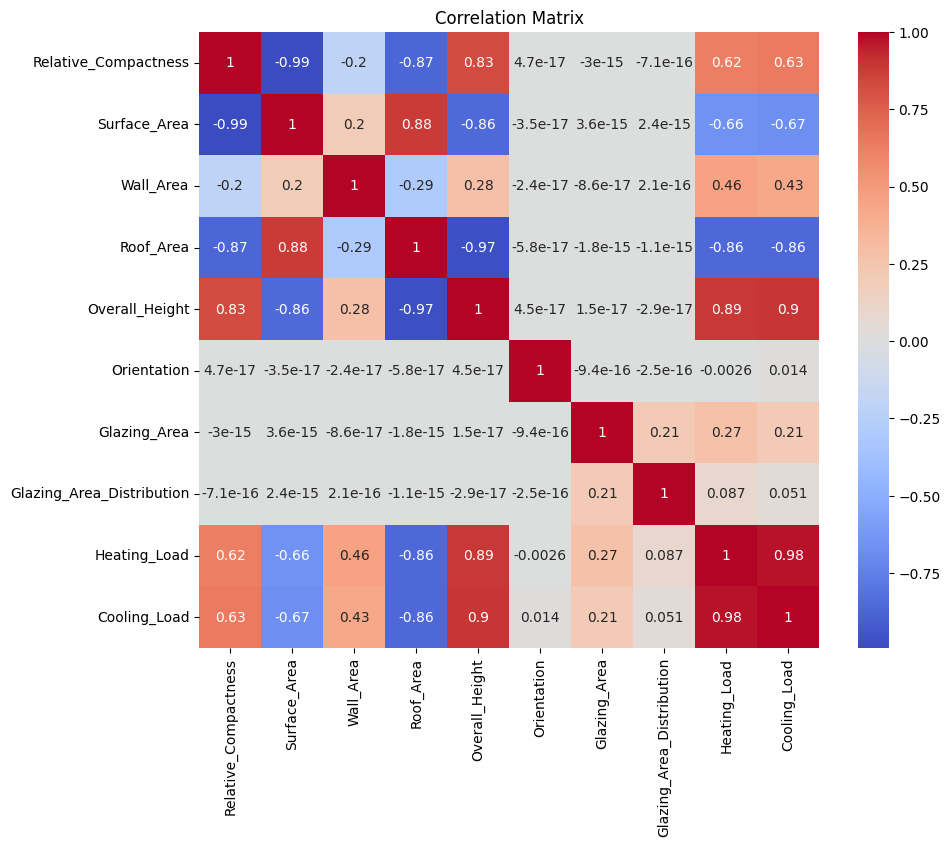

In [10]:
# 5. Visualize the correlation for features selection
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [11]:
# 6. Select input features and target variable
y = df["Cooling_Load"]
X = df[
    [
        "Relative_Compactness",
        "Surface_Area",
        "Wall_Area",
        "Roof_Area",
        "Overall_Height",
        "Glazing_Area"
    ]
]

In [12]:
# 7. Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
# 8. Train machine learning models
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [14]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor(random_state = 42)
dt.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [15]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state = 42)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [16]:
# 9. Make predictions using trained models
pred_lr=lr.predict(X_test)
pred_dt=dt.predict(X_test)
pred_rf=rf.predict(X_test)

In [17]:
# 10. Evaluate model performance
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "MAE": [
        mean_absolute_error(y_test, pred_lr),
        mean_absolute_error(y_test, pred_dt),
        mean_absolute_error(y_test, pred_rf)
    ],
    "MSE": [
        mean_squared_error(y_test, pred_lr),
        mean_squared_error(y_test, pred_dt),
        mean_squared_error(y_test, pred_rf)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, pred_lr)),
        np.sqrt(mean_squared_error(y_test, pred_dt)),
        np.sqrt(mean_squared_error(y_test, pred_rf))
    ],
    "R2 Score": [
        r2_score(y_test, pred_lr),
        r2_score(y_test, pred_dt),
        r2_score(y_test, pred_rf)
    ],

})

print(results)

               Model       MAE       MSE      RMSE  R2 Score
0  Linear Regression  2.201210  9.954203  3.155028  0.892570
1      Decision Tree  1.165358  3.055920  1.748119  0.967019
2      Random Forest  1.170107  3.060238  1.749354  0.966972


In [18]:
# 11. Save the best-performing model
import joblib
joblib.dump(dt, "decision_tree_cooling_model.pkl")

['decision_tree_cooling_model.pkl']